# 03 -- 用户行为分析

---

## 业务背景

获取一个新客户的成本是留住老客户的 5-7 倍。具体到我们的业务：

- 新客户贡献了多少 GMV？老客户贡献了多少？
- 用户来了之后，**留存率**如何？第 2 个月还有多少人回来？
- **复购周期**是多长？多久没来的用户算"流失"？
- 不同渠道、不同客群的留存有差异吗？

## 1. 环境与数据

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 加载数据
txn = pd.read_parquet('../output/transactions_wide.parquet')
customers = pd.read_parquet('../output/customers_clean.parquet')
sessions = pd.read_parquet('../output/sessions_clean.parquet')

completed = txn[txn['status'] == 'completed'].copy()

print(f"总用户数: {len(customers):,}")
print(f"有购买记录的用户: {completed['customer_id'].nunique():,}")
print(f"有会话记录的用户: {sessions['customer_id'].nunique():,}")

总用户数: 10,000
有购买记录的用户: 9,730
有会话记录的用户: 9,824


## 2. 新老客分析

定义：
- **新客** = 首次购买的用户
- **老客** = 非首次购买的用户

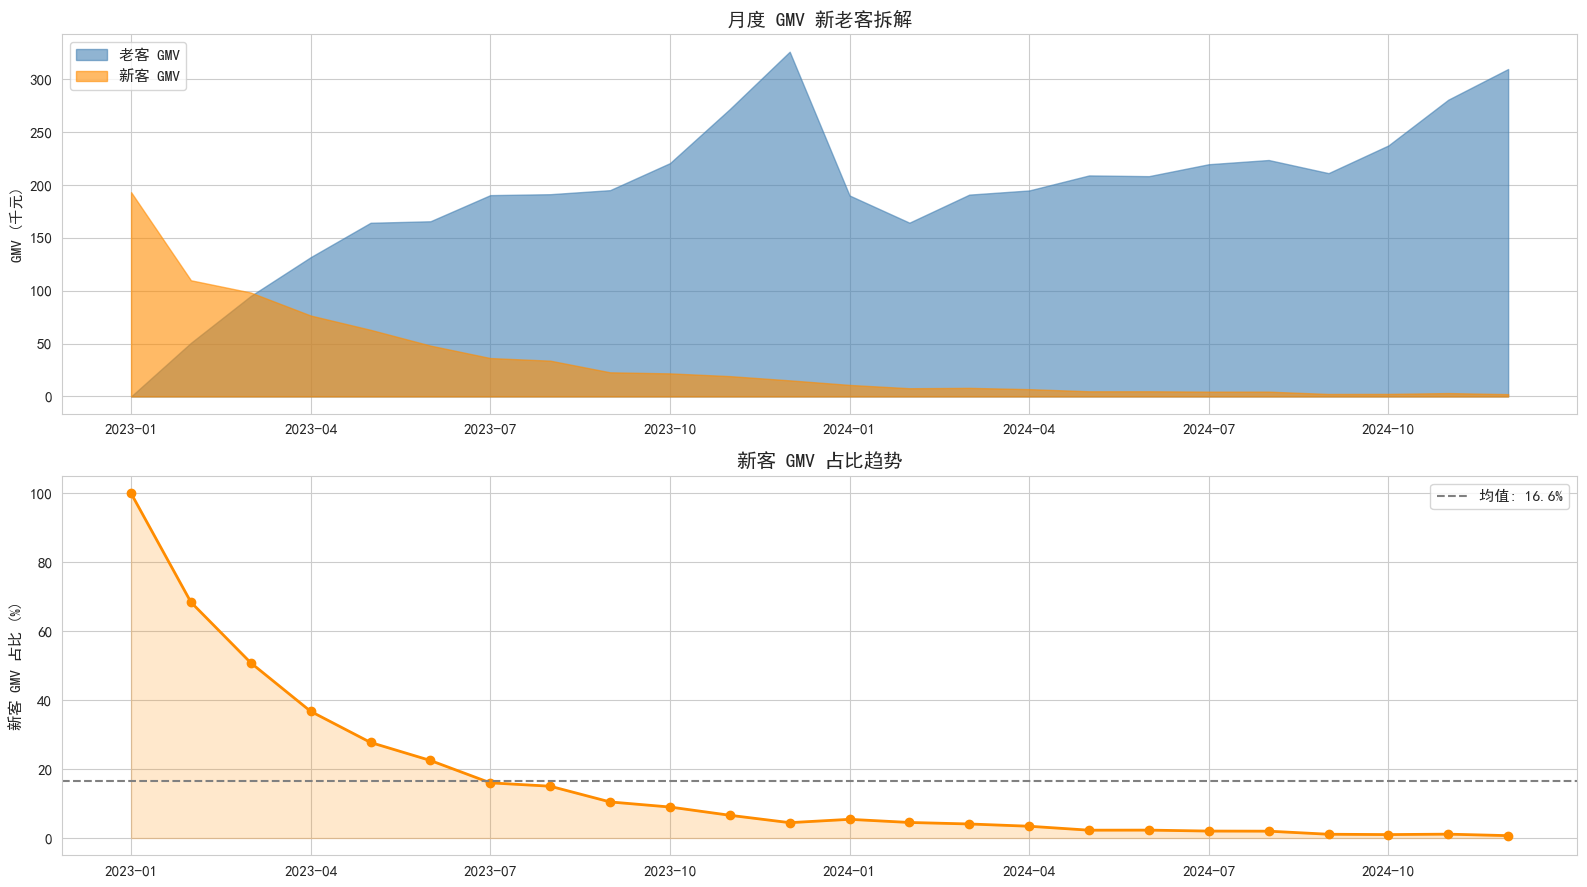

In [10]:
# 找出每个用户的首次购买月份
first_purchase = completed.groupby('customer_id')['year_month'].min().reset_index()
first_purchase.columns = ['customer_id', 'cohort_month']

# 为每笔订单打上新老客标签
completed = completed.merge(first_purchase, on='customer_id', how='left')
completed['is_new'] = (completed['year_month'] == completed['cohort_month']).astype(int)

# 按月汇总新老客 GMV
monthly_user = completed.groupby('year_month').agg(
    total_gmv=('total_amount', 'sum'),
    new_gmv=('total_amount', lambda x: x[completed.loc[x.index, 'is_new'] == 1].sum()),
    total_orders=('transaction_id', 'nunique'),
    total_customers=('customer_id', 'nunique'),
    new_customers=('is_new', 'sum')
).reset_index()
monthly_user['year_month'] = monthly_user['year_month'].astype(str)
monthly_user['old_gmv'] = monthly_user['total_gmv'] - monthly_user['new_gmv']
monthly_user['new_gmv_pct'] = monthly_user['new_gmv'] / monthly_user['total_gmv'] * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# GMV 新老客拆解
axes[0].fill_between(range(len(monthly_user)), monthly_user['old_gmv']/1000, alpha=0.6, color='steelblue', label='老客 GMV')
axes[0].fill_between(range(len(monthly_user)), monthly_user['new_gmv']/1000, alpha=0.6, color='darkorange', label='新客 GMV')
axes[0].set_title('月度 GMV 新老客拆解', fontsize=14, fontweight='bold')
axes[0].set_ylabel('GMV (千元)')
axes[0].set_xticks(range(0, len(monthly_user), 3))
axes[0].set_xticklabels(monthly_user['year_month'].iloc[::3])
axes[0].legend(loc='upper left')

# 新客 GMV 占比趋势
axes[1].plot(monthly_user['new_gmv_pct'], marker='o', color='darkorange', linewidth=2)
axes[1].fill_between(range(len(monthly_user)), monthly_user['new_gmv_pct'], alpha=0.2, color='darkorange')
axes[1].axhline(y=monthly_user['new_gmv_pct'].mean(), color='gray', linestyle='--',
                label=f"均值: {monthly_user['new_gmv_pct'].mean():.1f}%")
axes[1].set_title('新客 GMV 占比趋势', fontsize=14, fontweight='bold')
axes[1].set_ylabel('新客 GMV 占比 (%)')
axes[1].set_xticks(range(0, len(monthly_user), 3))
axes[1].set_xticklabels(monthly_user['year_month'].iloc[::3])
axes[1].legend()

plt.tight_layout()
plt.show()

**业务解读：**
- 如果新客 GMV 占比持续下降，老客 GMV 占比上升 → 健康的成熟业务
- 如果新客 GMV 占比突然飙升 → 可能在大量投放获客，需要关注这批用户的后续留存
- 如果总 GMV 增长但新客占比不变 → 获客和留存都在良性运转


## 3. 同期群留存分析

这是用户分析中**最有说服力**的一张图。它回答：每个月的获客，在后续几个月中还剩下多少活跃用户？

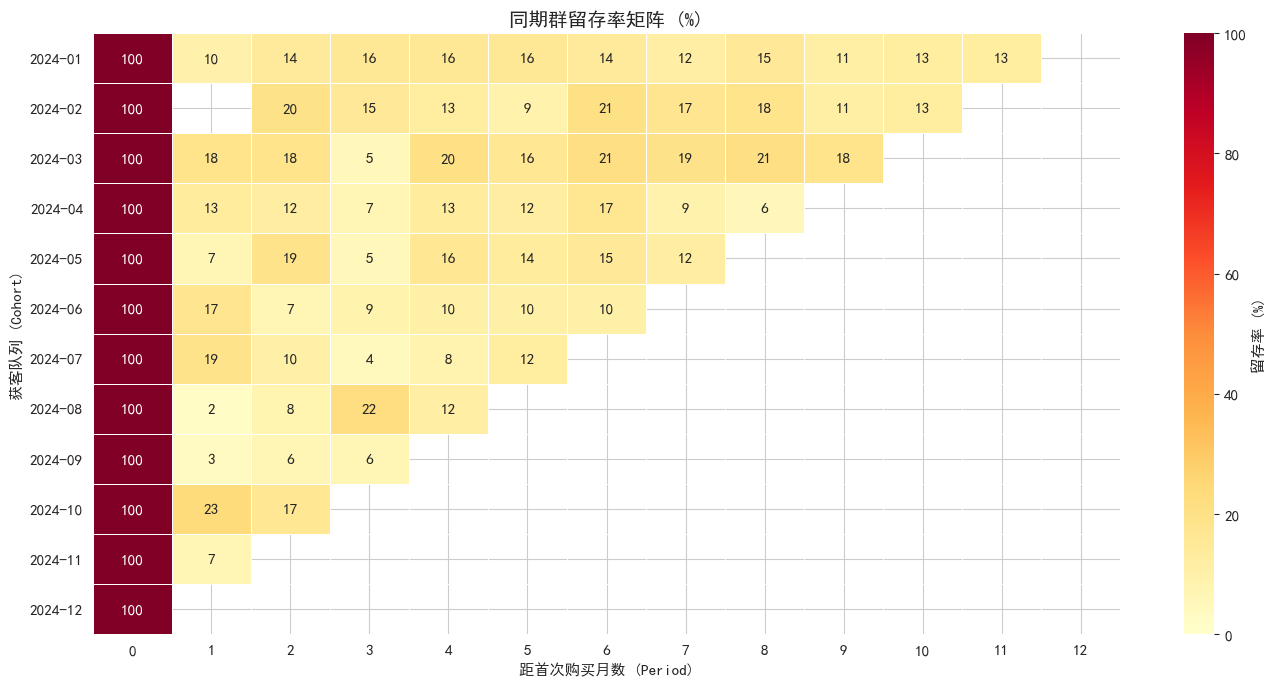

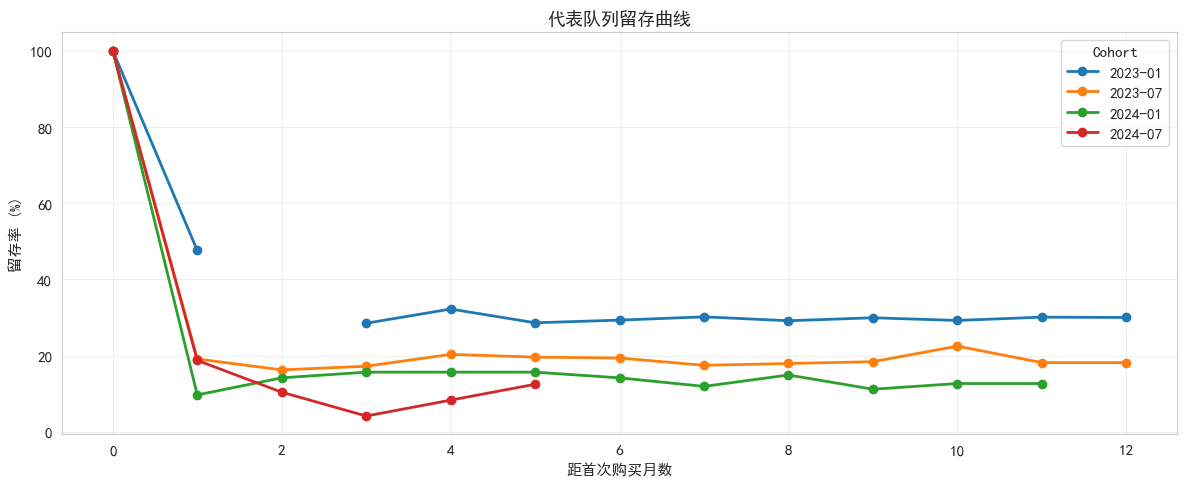

=== 平均留存率 ===
次月留存 (M1): 18.1%
3 月留存 (M3): 15.8%
6 月留存 (M6): 20.1%


In [11]:
# 构建 cohort 留存矩阵
first_purchase['cohort_month_str'] = first_purchase['cohort_month'].astype(str)

# 每月活跃用户
active_users = completed.groupby(['customer_id', 'year_month']).size().reset_index()
active_users.columns = ['customer_id', 'active_month', 'cnt']
active_users['active_month'] = active_users['active_month'].astype(str)

# Merge: 每个用户的活跃月 + 其首购月
cohort_data = active_users.merge(
    first_purchase[['customer_id', 'cohort_month_str']],
    on='customer_id', how='left'
)
cohort_data['period'] = (
    pd.to_datetime(cohort_data['active_month']) - pd.to_datetime(cohort_data['cohort_month_str'])
).dt.days // 30

# 只看 period 0-12（前12个月留存）
cohort_data = cohort_data[(cohort_data['period'] >= 0) & (cohort_data['period'] <= 12)]

# 构建留存矩阵
cohort_size = first_purchase.groupby('cohort_month_str').size()
retention = cohort_data.groupby(['cohort_month_str', 'period'])['customer_id'].nunique().unstack()

# 除以 cohort 初始人数
for cohort in retention.index:
    if cohort in cohort_size.index:
        retention.loc[cohort] = retention.loc[cohort] / cohort_size[cohort] * 100

# 可视化（取最近的 12 个 cohort）
recent_cohorts = retention.index[-12:]
retention_plot = retention.loc[recent_cohorts]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    retention_plot.clip(upper=100),
    annot=True, fmt='.0f', cmap='YlOrRd',
    vmin=0, vmax=100, linewidths=0.5, linecolor='white',
    cbar_kws={'label': '留存率 (%)'},
    ax=ax
)
ax.set_title('同期群留存率矩阵 (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('距首次购买月数 (Period)')
ax.set_ylabel('获客队列 (Cohort)')

plt.tight_layout()
plt.show()

# 留存曲线（取几个代表队列）
fig, ax = plt.subplots(figsize=(12, 5))
representative = retention.index[::6]  # 每6个月取一个
for cohort in representative:
    ax.plot(retention.columns, retention.loc[cohort], marker='o', linewidth=2, label=cohort)
ax.set_title('代表队列留存曲线', fontsize=13, fontweight='bold')
ax.set_xlabel('距首次购买月数')
ax.set_ylabel('留存率 (%)')
ax.legend(title='Cohort')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 关键指标
avg_m1_retention = retention[1].mean() if 1 in retention.columns else np.nan
avg_m3_retention = retention[3].mean() if 3 in retention.columns else np.nan
avg_m6_retention = retention[6].mean() if 6 in retention.columns else np.nan
print(f"=== 平均留存率 ===")
print(f"次月留存 (M1): {avg_m1_retention:.1f}%")
print(f"3 月留存 (M3): {avg_m3_retention:.1f}%")
print(f"6 月留存 (M6): {avg_m6_retention:.1f}%")

**业务解读——这张图怎么读：**

- **横向看**（同一行）：某一个月的获客，随着时间推移，剩下多少人还在买？下降越快说明"漏得越厉害"
- **纵向看**（同一列）：不同月份来的用户，在同样的第 N 个月的留存率是否在改善？
- 如果 M1 留存低于 20%，说明首单体验有问题——用户买了一次就走了
- 如果 M3-M6 留存趋于平稳（~10-15%），说明留下的用户进入了稳定复购期

**这是运营最关注的指标：** 提升 M1 留存 5%，比拉新成本降低 20% 更值钱。


## 4. 复购周期分析

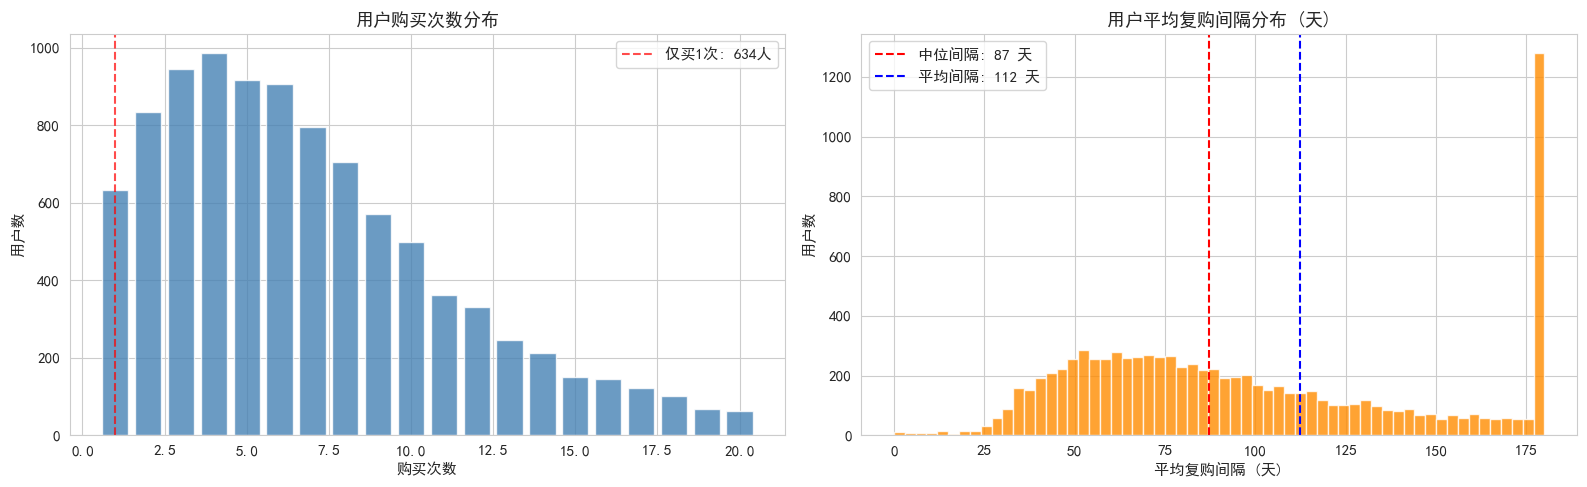

=== 复购概览 ===
仅购买 1 次的用户: 634 / 9,730 (6.5%)
复购 2 次及以上: 9,096 (93.5%)
平均购买次数: 7.1
中位复购间隔: 87 天
平均复购间隔: 112 天


In [12]:
# 计算每用户的平均复购间隔
user_orders = completed.groupby('customer_id').agg(
    order_count=('transaction_id', 'nunique'),
    first_order=('transaction_date', 'min'),
    last_order=('transaction_date', 'max'),
    total_spent=('total_amount', 'sum')
).reset_index()

# 只保留有 2 次以上购买的用户
repeat_users = user_orders[user_orders['order_count'] >= 2].copy()
repeat_users['days_between'] = (repeat_users['last_order'] - repeat_users['first_order']).dt.days
repeat_users['avg_interval'] = repeat_users['days_between'] / (repeat_users['order_count'] - 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 复购次数分布
order_dist = user_orders['order_count'].value_counts().sort_index()
order_dist_plot = order_dist[order_dist.index <= 20]  # 只看 1-20 次
axes[0].bar(order_dist_plot.index, order_dist_plot.values, color='steelblue', alpha=0.8)
axes[0].set_title('用户购买次数分布', fontsize=13, fontweight='bold')
axes[0].set_xlabel('购买次数')
axes[0].set_ylabel('用户数')
axes[0].axvline(x=1, color='red', linestyle='--', alpha=0.7, label=f"仅买1次: {order_dist.get(1, 0):,}人")
axes[0].legend()

# 复购间隔分布
axes[1].hist(repeat_users['avg_interval'].clip(upper=180), bins=60,
             color='darkorange', alpha=0.8, edgecolor='white')
axes[1].axvline(x=repeat_users['avg_interval'].median(), color='red', linestyle='--',
                label=f"中位间隔: {repeat_users['avg_interval'].median():.0f} 天")
axes[1].axvline(x=repeat_users['avg_interval'].mean(), color='blue', linestyle='--',
                label=f"平均间隔: {repeat_users['avg_interval'].mean():.0f} 天")
axes[1].set_title('用户平均复购间隔分布 (天)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('平均复购间隔 (天)')
axes[1].set_ylabel('用户数')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"=== 复购概览 ===")
print(f"仅购买 1 次的用户: {order_dist.get(1, 0):,} / {len(user_orders):,} ({order_dist.get(1, 0)/len(user_orders):.1%})")
print(f"复购 2 次及以上: {len(repeat_users):,} ({len(repeat_users)/len(user_orders):.1%})")
print(f"平均购买次数: {user_orders['order_count'].mean():.1f}")
print(f"中位复购间隔: {repeat_users['avg_interval'].median():.0f} 天")
print(f"平均复购间隔: {repeat_users['avg_interval'].mean():.0f} 天")

**业务解读：**
- 中位复购间隔 > 平均复购间隔 → 说明有一批"重度用户"拉高了均值，大多数用户的复购周期更长
- 如果中位间隔是 60 天，那 60 天没来的用户就该开始做召回触达了
- 仅买 1 次的用户占比如果超过 50% → 首单转化后的留存体系有严重问题


## 5. 用户生命周期价值 (LTV) 分布

LTV 衡量的是每个用户在整个生命周期中贡献的总价值。

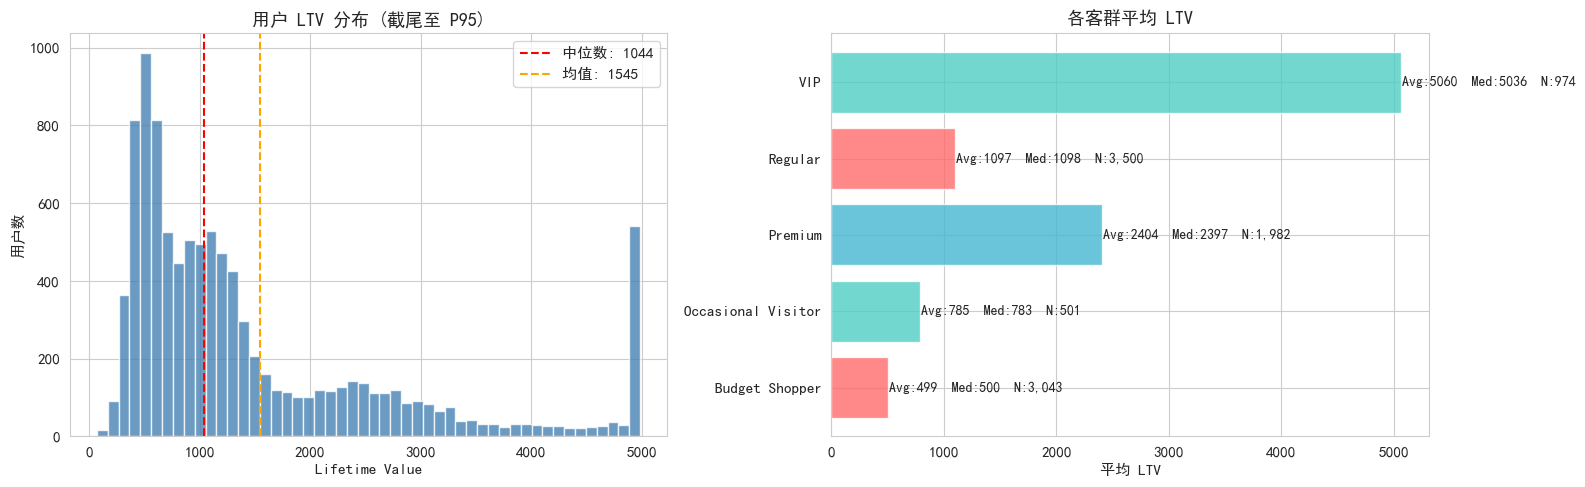

=== LTV 集中度 ===
Top 10% 用户 LTV 阈值: 3,361
Top 10% 用户数: 1,000
Top 10% LTV 占比总 LTV: 32.9%


In [13]:
# 已有 lifetime_value 字段，直接分析分布
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LTV 分布
axes[0].hist(customers['lifetime_value'].clip(upper=customers['lifetime_value'].quantile(0.95)),
             bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(x=customers['lifetime_value'].median(), color='red', linestyle='--',
                label=f"中位数: {customers['lifetime_value'].median():.0f}")
axes[0].axvline(x=customers['lifetime_value'].mean(), color='orange', linestyle='--',
                label=f"均值: {customers['lifetime_value'].mean():.0f}")
axes[0].set_title('用户 LTV 分布 (截尾至 P95)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lifetime Value')
axes[0].set_ylabel('用户数')
axes[0].legend()

# 按 segment 的 LTV 分布
segments = customers.groupby('segment')['lifetime_value'].agg(['mean', 'median', 'count'])
axes[1].barh(segments.index, segments['mean'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[1].set_title('各客群平均 LTV', fontsize=13, fontweight='bold')
axes[1].set_xlabel('平均 LTV')
for i, (mean, med, cnt) in enumerate(zip(segments['mean'], segments['median'], segments['count'])):
    axes[1].text(mean + 10, i, f'Avg:{mean:.0f}  Med:{med:.0f}  N:{cnt:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# LTV Top 10% 用户贡献
top10_threshold = customers['lifetime_value'].quantile(0.90)
top10_ltv = customers[customers['lifetime_value'] >= top10_threshold]
print(f"=== LTV 集中度 ===")
print(f"Top 10% 用户 LTV 阈值: {top10_threshold:,.0f}")
print(f"Top 10% 用户数: {len(top10_ltv):,}")
print(f"Top 10% LTV 占比总 LTV: {top10_ltv['lifetime_value'].sum() / customers['lifetime_value'].sum():.1%}")

**业务解读：**
- LTV 分布高度右偏是正常现象——少数高价值用户贡献大部分价值
- 如果 Top 10% 用户贡献了 40%+ 的总 LTV，说明维护好这批核心用户就是维护好生意的基本盘
- 这就是为什么接下来要做 RFM 分层——找到不同价值的用户，做差异化运营


## 6. 流失用户画像

数据集中已有 `is_churned` 标签，来看看流失用户有什么特征。

=== 流失 vs 非流失用户特征 ===
             用户数   平均年龄    平均LTV  邮件订阅率  APP使用率
is_churned                                     
0           8306  35.27  1665.19    0.7    0.55
1           1694  35.64   953.37    0.7    0.58


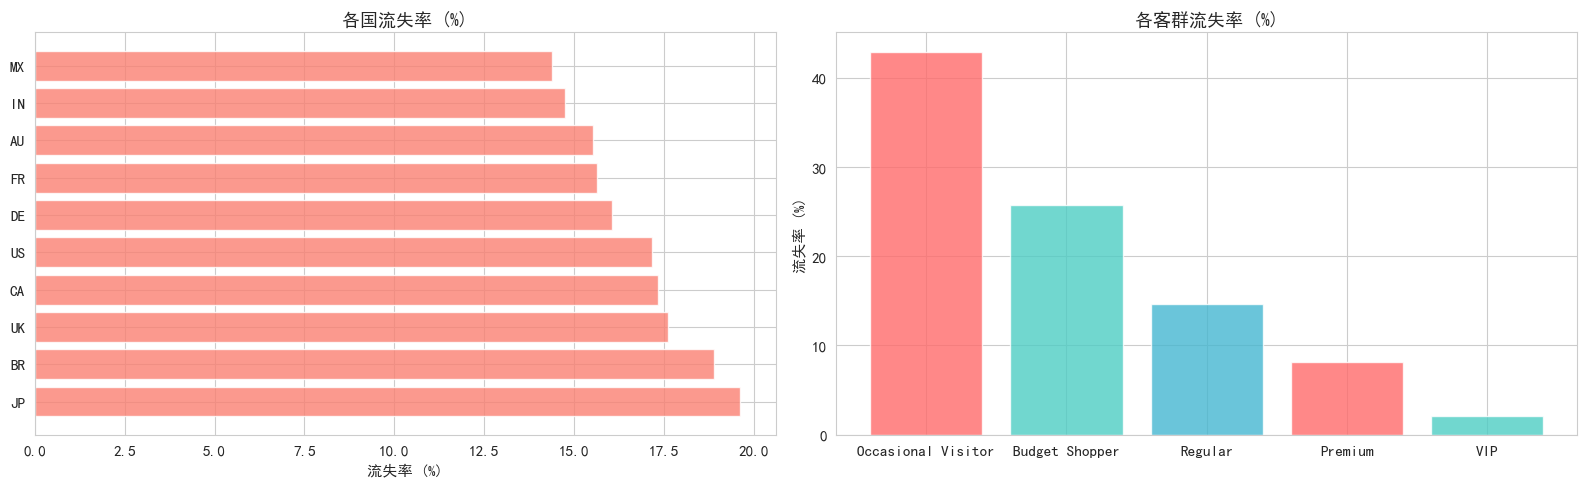


整体流失率: 16.9%


In [14]:
# 流失 vs 非流失用户特征对比
churn_profile = customers.groupby('is_churned').agg(
    用户数=('customer_id', 'nunique'),
    平均年龄=('age', 'mean'),
    平均LTV=('lifetime_value', 'mean'),
    邮件订阅率=('email_opt_in', 'mean'),
    APP使用率=('has_app', 'mean')
).round(2)

print("=== 流失 vs 非流失用户特征 ===")
print(churn_profile.to_string())

# 按国家和客群看流失率
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

churn_by_country = customers.groupby('country')['is_churned'].mean().sort_values(ascending=False)
axes[0].barh(churn_by_country.index, churn_by_country.values * 100, color='salmon', alpha=0.8)
axes[0].set_title('各国流失率 (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('流失率 (%)')

churn_by_segment = customers.groupby('segment')['is_churned'].mean().sort_values(ascending=False)
axes[1].bar(churn_by_segment.index, churn_by_segment.values * 100,
            color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[1].set_title('各客群流失率 (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('流失率 (%)')

plt.tight_layout()
plt.show()

print(f"\n整体流失率: {customers['is_churned'].mean():.1%}")

**业务解读：**
- 如果 Budget Shopper 流失率明显更高 → 说明低价客群忠诚度低，需要通过会员体系或积分系统来绑定
- 如果 APP 使用率高的用户流失率更低 → 说明 APP 是留存利器，值得推动更多用户下载
- 流失率在国家维度的差异，可以帮助优化不同市场的运营策略


---

## 7.小结

| 分析维度 | 关键发现 | 运营策略 |
|----------|---------|---------|
| 新老客贡献 | 见占比趋势 | 老客稳基本盘，新客保增长 |
| 同期群留存 | M1 留存决定用户生命周期价值 | 首单后 7 天内触达是黄金窗口 |
| 复购周期 | 中位间隔 ≈ N 天 | 超过 N 天未回购启动召回 |
| LTV 集中度 | Top 10% 贡献 X% | 高价值用户专属客服 + VIP 权益 |
| 流失用户画像 | APP 用户流失率更低 | Push 安装 APP 的用户福利 |

**核心结论：** 用户增长的质量，不看获客数，看留存率。Cohort Retention 是整个用户分析中最值得拿给老板看的一张图。
